Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Load Dataset

In [3]:
dataset = pd.read_csv("D:\Assignment\Task-2 Clustering Model\Dataset\spotify_data.csv")
dataset = dataset.sample(80000, random_state=42)
dataset.head()

,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
882616,1054304,Cabas,Amor De Mis Amores,3FTqjWmL21xi4HTTOq94EQ,38,2006,alt-rock,0.725,0.553,6,-6.319,0,0.0340,0.276000,0.000007,0.1850,0.729,90.009,206653,4
621408,621408,Ketil Bjørnstad,Første sang,0Pt7ESPgrdTdaxp2f29hX2,11,2023,swedish,0.277,0.164,9,-16.743,0,0.0373,0.878000,0.000181,0.3350,0.184,89.308,459733,4
927704,1121669,Project 86,Evil (A Chorus Of Resistance),75Ub3ckaoTdzgH9Azeu8cY,38,2007,alt-rock,0.486,0.927,2,-4.845,0,0.0428,0.000003,0.014500,0.0952,0.377,135.540,183373,4
439351,439351,Ital Tek,Open Heart,5WEPna9GWi0NkqVLAkEKNN,18,2020,dubstep,0.411,0.442,1,-12.745,0,0.0270,0.485000,0.926000,0.1910,0.172,174.019,347610,3
266036,266036,I-Roy,Irie Right,6peHySxvmZaRF9YEwUsggq,18,2017,dancehall,0.748,0.660,10,-4.648,0,0.2710,0.125000,0.000000,0.0783,0.400,75.583,196179,4


Dataset Information

In [4]:
print("Dataset Shape:")
print(dataset.shape)

print("\nDataset Info:")
print(dataset.info())

print("\nDataset Description:")
print(dataset.describe())

Dataset Shape:
(80000, 20)

Dataset Info:
<class 'pandas.DataFrame'>
Index: 80000 entries, 882616 to 782043
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        80000 non-null  int64  
 1   artist_name       80000 non-null  str    
 2   track_name        80000 non-null  str    
 3   track_id          80000 non-null  str    
 4   popularity        80000 non-null  int64  
 5   year              80000 non-null  int64  
 6   genre             80000 non-null  str    
 7   danceability      80000 non-null  float64
 8   energy            80000 non-null  float64
 9   key               80000 non-null  int64  
 10  loudness          80000 non-null  float64
 11  mode              80000 non-null  int64  
 12  speechiness       80000 non-null  float64
 13  acousticness      80000 non-null  float64
 14  instrumentalness  80000 non-null  float64
 15  liveness          80000 non-null  float64
 16  valence 

Feature Selection

In [5]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]
X = dataset[features]
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
882616,0.725,0.553,-6.319,0.0340,0.276000,0.000007,0.1850,0.729,90.009,206653
621408,0.277,0.164,-16.743,0.0373,0.878000,0.000181,0.3350,0.184,89.308,459733
927704,0.486,0.927,-4.845,0.0428,0.000003,0.014500,0.0952,0.377,135.540,183373
439351,0.411,0.442,-12.745,0.0270,0.485000,0.926000,0.1910,0.172,174.019,347610
266036,0.748,0.660,-4.648,0.2710,0.125000,0.000000,0.0783,0.400,75.583,196179


Check Missing Values

In [6]:
print(X.isnull().sum())

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
dtype: int64


Handle Missing Values

In [7]:
X = X.dropna()

Feature Scaling

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 1.0154437  -0.32513105  0.4662043  ...  1.01075062 -1.05406801
  -0.28843236]
 [-1.42402669 -1.76982832 -1.38054336 ... -1.01448758 -1.07753143
   1.45351379]
 [-0.28597019  1.06385809  0.72734264 ... -0.29729313  0.46991641
  -0.44866828]
 ...
 [-1.75618673 -1.14589736 -0.3576039  ... -1.5622309  -1.39092376
   2.08968756]
 [-1.75074148  1.18641596  1.19469877 ... -0.4162062   0.41037086
  -0.48066729]
 [ 1.28226078 -2.00788769 -1.28576113 ... -0.64660027 -0.84654559
  -1.38304743]]


Elbow Method

In [9]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

Elbow Method Visualization

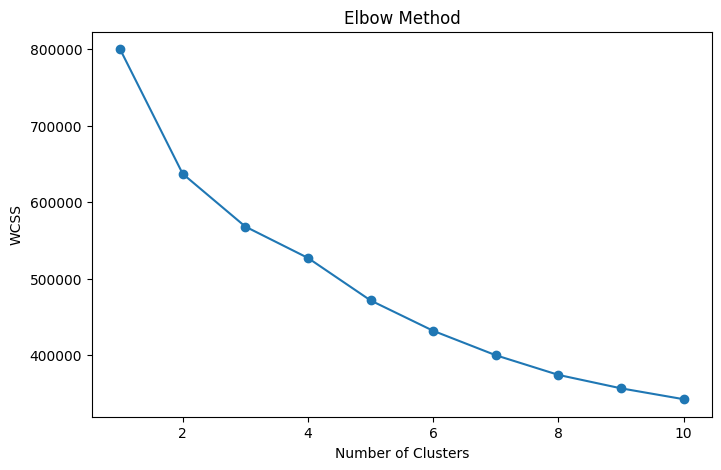

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.savefig("../outputs/elbow_method.png")
plt.show()

Apply K-Means Clustering

In [11]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X_scaled)

print(y_kmeans)


[3 2 0 ... 0 0 1]


Add Cluster Labels

In [12]:
X['KMeans_Cluster'] = y_kmeans
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,KMeans_Cluster
882616,0.725,0.553,-6.319,0.0340,0.276000,0.000007,0.1850,0.729,90.009,206653,3
621408,0.277,0.164,-16.743,0.0373,0.878000,0.000181,0.3350,0.184,89.308,459733,2
927704,0.486,0.927,-4.845,0.0428,0.000003,0.014500,0.0952,0.377,135.540,183373,0
439351,0.411,0.442,-12.745,0.0270,0.485000,0.926000,0.1910,0.172,174.019,347610,0
266036,0.748,0.660,-4.648,0.2710,0.125000,0.000000,0.0783,0.400,75.583,196179,3


Silhouette Score

In [13]:
sample_size = 80000

score = silhouette_score(
    X_scaled,
    y_kmeans,
    sample_size=sample_size,
    random_state=42
)

print("Silhouette Score:", score)

Silhouette Score: 0.164973193893803


Apply DBSCAN

In [14]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)
X['DBSCAN_Cluster'] = y_dbscan

PCA for 2D Visualization

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

K-Means Visualization

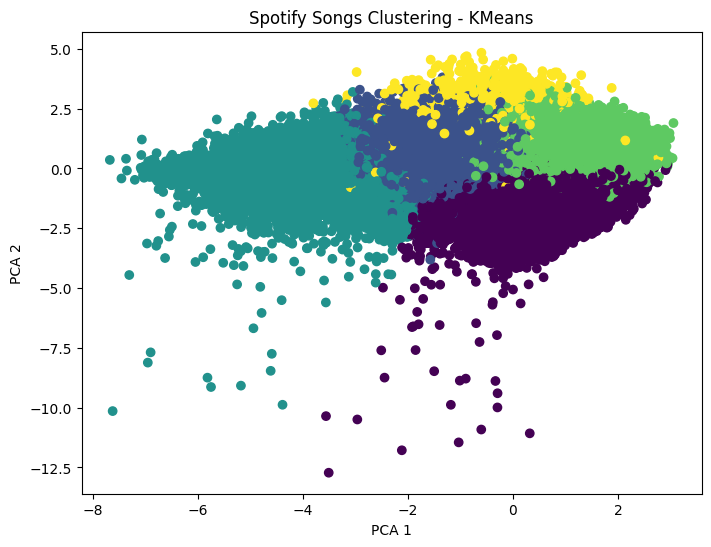

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_kmeans,
    cmap='viridis'
)

plt.title("Spotify Songs Clustering - KMeans")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.savefig("../outputs/kmeans_clusters.png")

plt.show()

DBSCAN Visualization

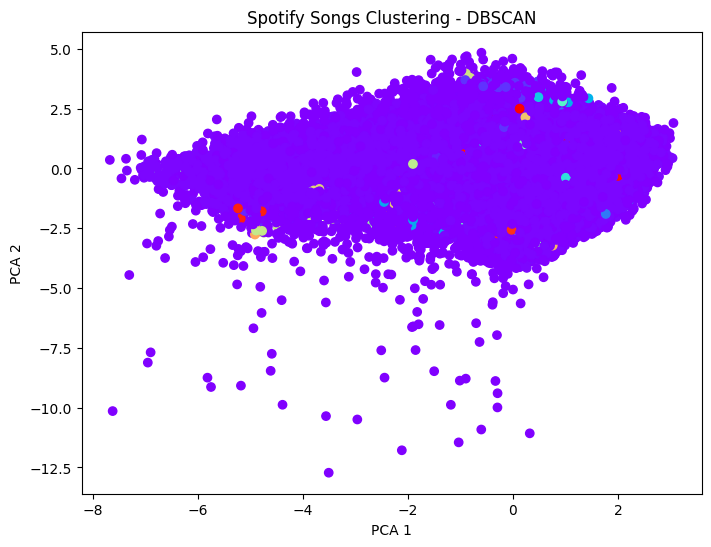

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_dbscan,
    cmap='rainbow'
)

plt.title("Spotify Songs Clustering - DBSCAN")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.savefig("../outputs/dbscan_clusters.png")

plt.show()

PCA for 3D Visualization

In [18]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

3D K-Means Visualization

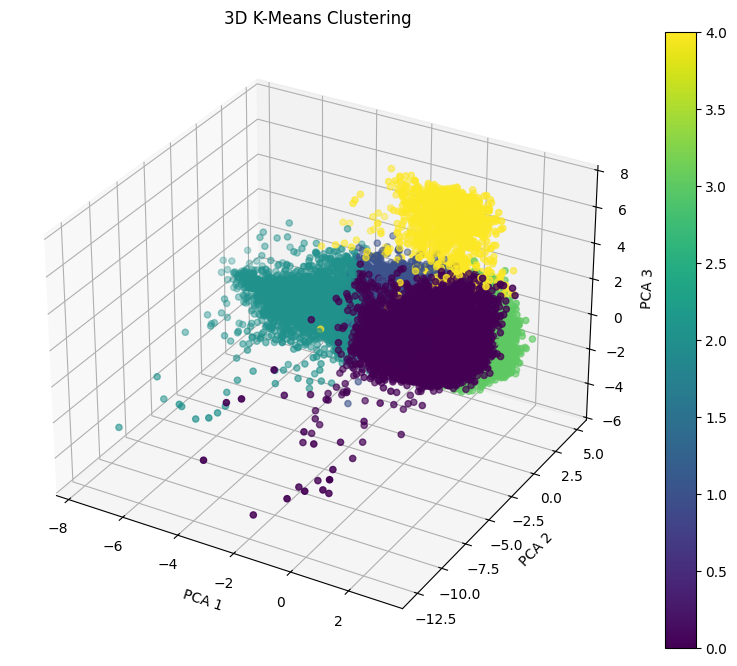

In [19]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=y_kmeans,
    cmap='viridis'
)
ax.set_title("3D K-Means Clustering")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
plt.colorbar(scatter)
plt.savefig("../outputs/kmeans_3d_clusters.png")
plt.show()

3D DBSCAN Visualization

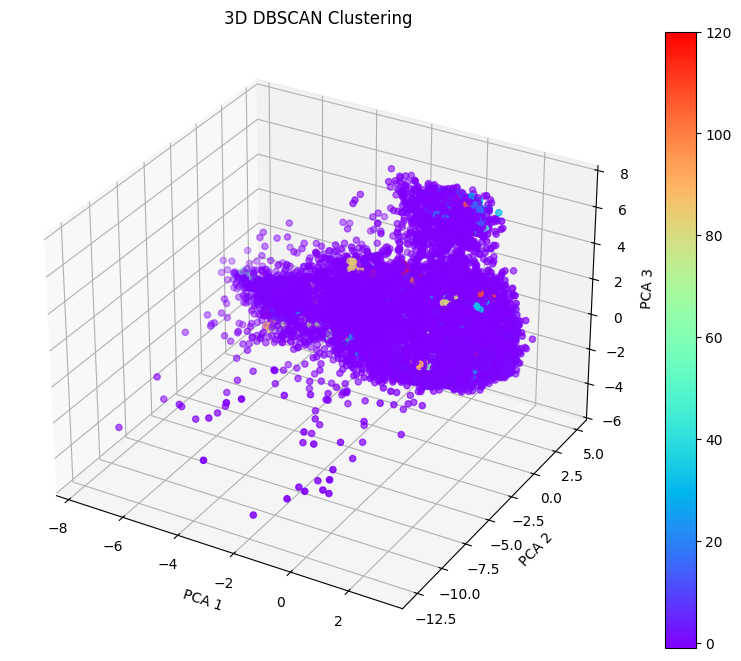

In [20]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=y_dbscan,
    cmap='rainbow'
)
ax.set_title("3D DBSCAN Clustering")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
plt.colorbar(scatter)
plt.savefig("../outputs/dbscan_3d_clusters.png")
plt.show()

Save Clustered Dataset

In [21]:
X.to_csv(
    "../outputs/Clustered_Output.csv",
    index=False
)
print("Clustered dataset saved successfully")

Clustered dataset saved successfully


Add Cluster Labels

In [23]:
X['KMeans_Cluster'] = y_kmeans

Feature-wise Cluster Mean Analysis

In [22]:

cluster_feature_analysis = X.groupby('KMeans_Cluster').mean()
print(cluster_feature_analysis)

                danceability    energy   loudness  speechiness  acousticness  \
KMeans_Cluster                                                                 
0                   0.453169  0.828187  -6.348614     0.088425      0.053000   
1                   0.527063  0.390436 -10.729875     0.057416      0.676436   
2                   0.336407  0.170637 -21.302492     0.050285      0.867147   
3                   0.675200  0.742141  -6.685369     0.091963      0.191205   
4                   0.574130  0.613539 -12.699734     0.831447      0.721235   

                instrumentalness  liveness   valence       tempo  \
KMeans_Cluster                                                     
0                       0.339182  0.266774  0.299592  133.642473   
1                       0.116896  0.200616  0.404007  113.825220   
2                       0.761967  0.151367  0.187164  104.047833   
3                       0.113910  0.196568  0.700462  120.719159   
4                       0.02256

Heatmap Visualization

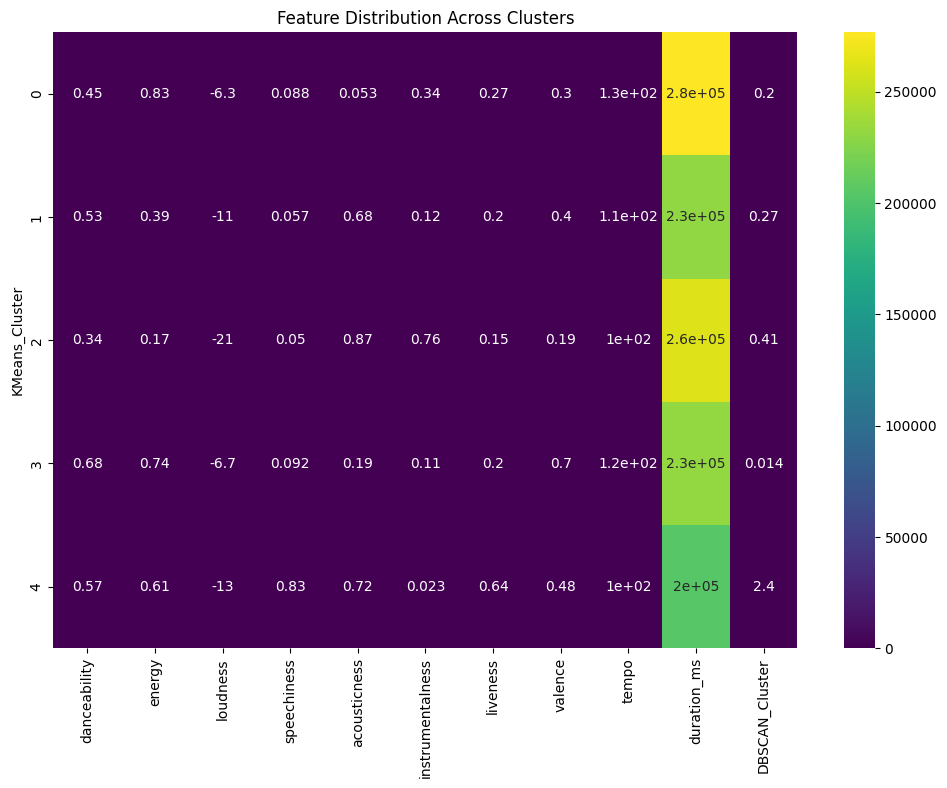

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(
    cluster_feature_analysis,
    annot=True,
    cmap='viridis'
)
plt.title("Feature Distribution Across Clusters")
plt.savefig("../outputs/feature_cluster_heatmap.png")
plt.show()

Individual Feature Graphs

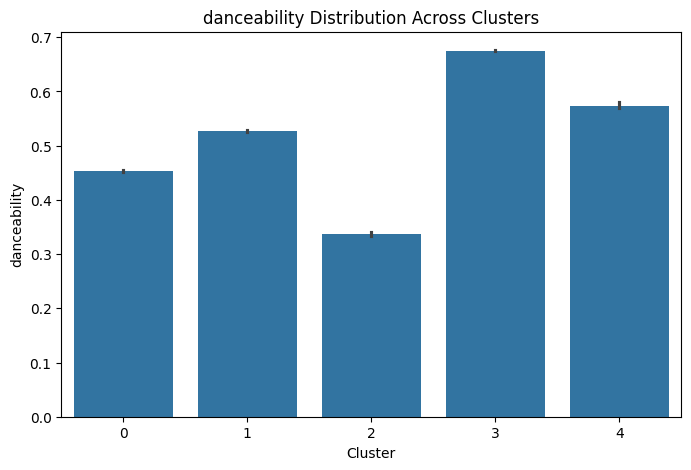

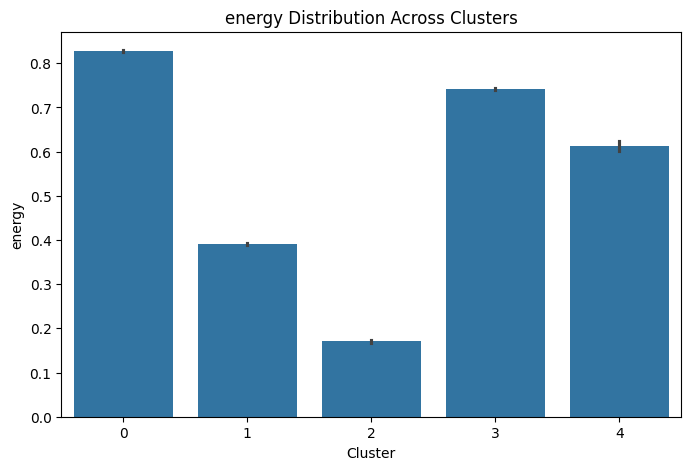

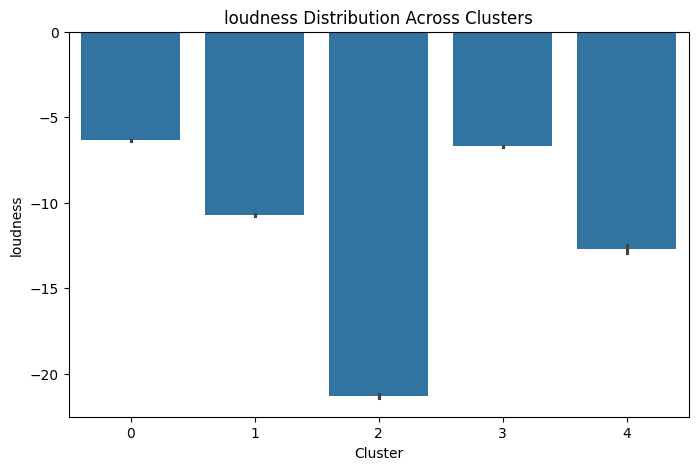

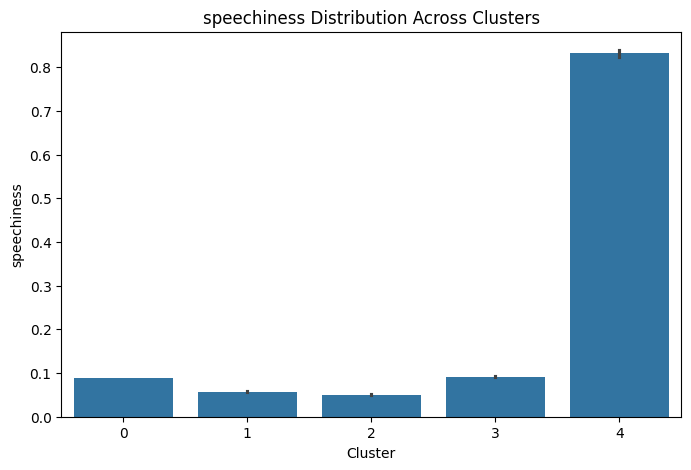

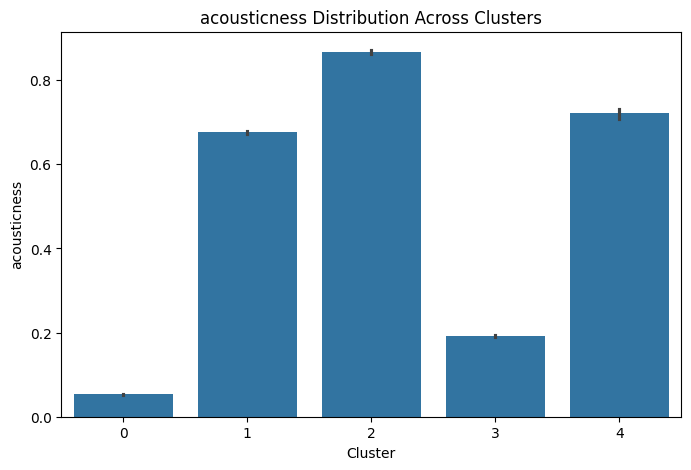

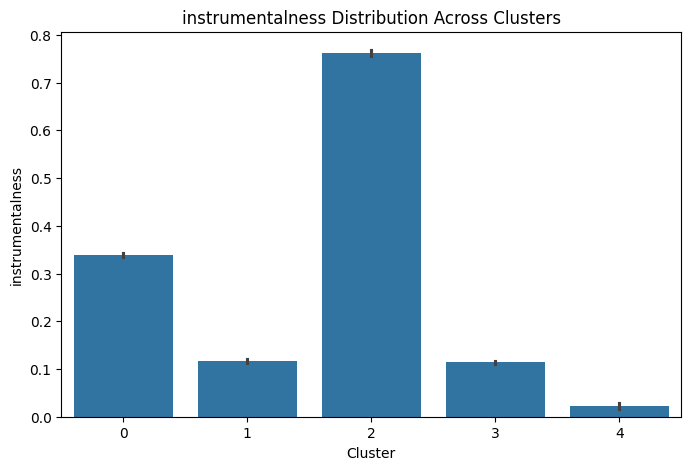

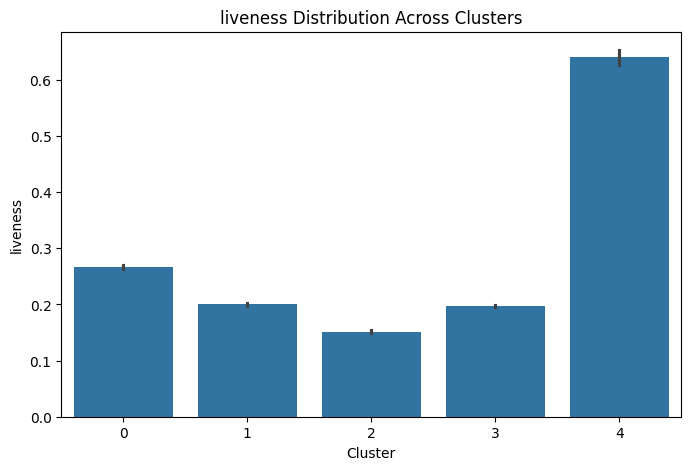

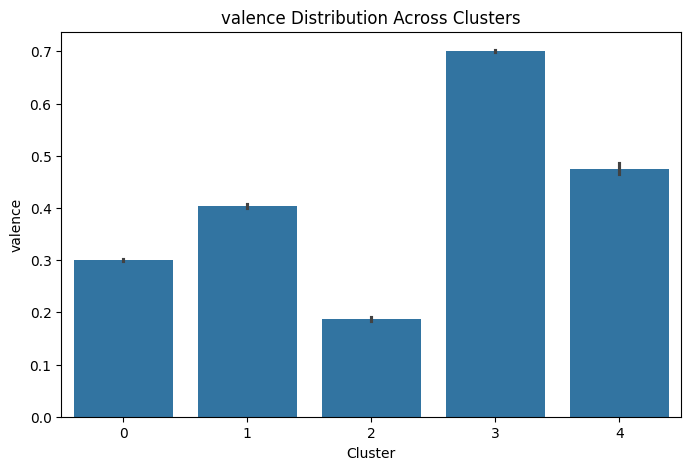

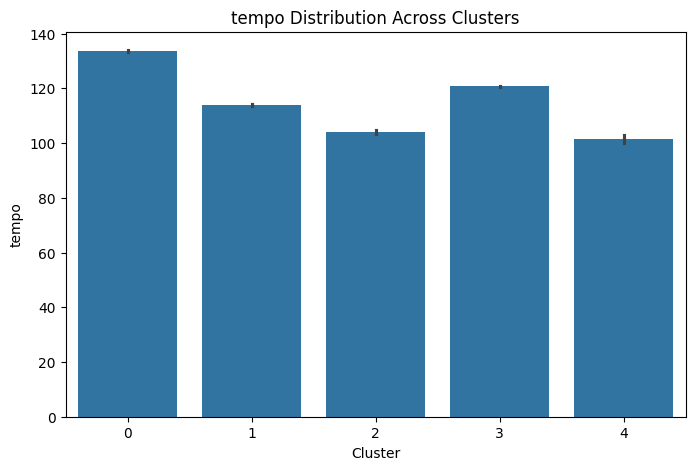

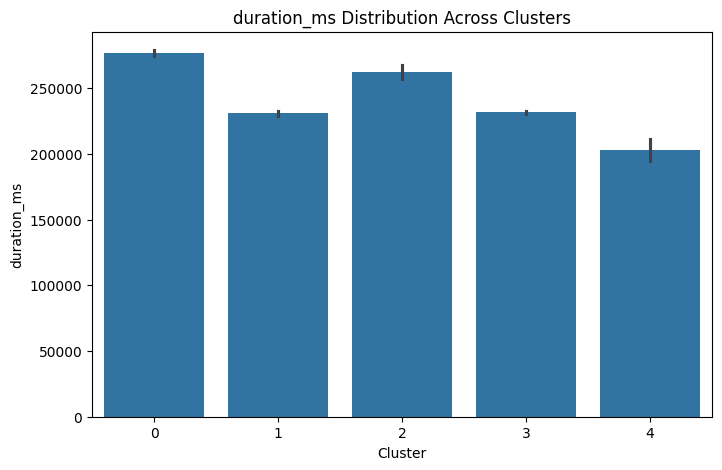

In [25]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]
for feature in features:
    plt.figure(figsize=(8,5))
    sns.barplot(
        x='KMeans_Cluster',
        y=feature,
        data=X
    )
    plt.title(f"{feature} Distribution Across Clusters")
    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.savefig(f"../outputs/{feature}_cluster.png")
    plt.show()

Save KMeans Model

In [26]:
import joblib
joblib.dump(kmeans, "../outputs/kmeans_model.pkl")
print("KMeans model saved successfully")


KMeans model saved successfully


Load Saved Model

In [27]:
loaded_model = joblib.load("../outputs/kmeans_model.pkl")
print("Model loaded successfully")

Model loaded successfully


New Song Input for Inference

In [28]:
new_song = pd.DataFrame([{
    'danceability': 0.78,
    'energy': 0.85,
    'loudness': -4.5,
    'speechiness': 0.05,
    'acousticness': 0.10,
    'instrumentalness': 0.00,
    'liveness': 0.12,
    'valence': 0.90,
    'tempo': 130.0,
    'duration_ms': 210000
}])

Scale Input Data

In [29]:
new_song_scaled = scaler.transform(new_song)

Predict Cluster


In [30]:
predicted_cluster = loaded_model.predict(new_song_scaled)
print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 3


Cluster Interpretation

In [31]:
cluster_names = { 0: "Dance Songs",
    1: "Sad Songs",
    2: "Love Songs",
    3: "Vibe Songs",
    4: "Relax Songs"}
print(new_song)
print("Song Category:",
    cluster_names[predicted_cluster[0]])

   danceability  energy  loudness  speechiness  acousticness  \
0          0.78    0.85      -4.5         0.05           0.1   

   instrumentalness  liveness  valence  tempo  duration_ms  
0               0.0      0.12      0.9  130.0       210000  
Song Category: Vibe Songs


NEW SONG INPUT FOR INFERENCE

In [48]:
new_song = pd.DataFrame([{
    'danceability': 0.74,
    'energy': 0.68,
    'loudness': -5.8,
    'speechiness': 0.04,
    'acousticness': 0.32,
    'instrumentalness': 0.00,
    'liveness': 0.14,
    'valence': 0.88,
    'tempo': 112.0,
    'duration_ms': 245000
}])
predicted_cluster = loaded_model.predict(new_song_scaled)
print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 3


In [49]:
cluster_names = {0: "Dance Songs",
    1: "Sad Songs",
    2: "Love Songs",
    3: "Vibe Songs",
    4: "Relax Songs"}
print(new_song)
print("Song Category:",
    cluster_names[predicted_cluster[0]])

   danceability  energy  loudness  speechiness  acousticness  \
0          0.74    0.68      -5.8         0.04          0.32   

   instrumentalness  liveness  valence  tempo  duration_ms  
0               0.0      0.14     0.88  112.0       245000  
Song Category: Vibe Songs


In [ ]:
songs = pd.DataFrame([

    {
        'song_name': 'Mudhal Nee Mudivum Nee',
        'danceability': 0.74,
        'energy': 0.68,
        'loudness': -5.8,
        'speechiness': 0.04,
        'acousticness': 0.32,
        'instrumentalness': 0.00,
        'liveness': 0.14,
        'valence': 0.88,
        'tempo': 112.0,
        'duration_ms': 245000
    },

    {
        'song_name': 'New York Nagaram',
        'danceability': 0.62,
        'energy': 0.48,
        'loudness': -7.8,
        'speechiness': 0.03,
        'acousticness': 0.58,
        'instrumentalness': 0.00,
        'liveness': 0.11,
        'valence': 0.42,
        'tempo': 92.0,
        'duration_ms': 320000 }
    ])

features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms']

songs_scaled = scaler.transform(
    songs[features])

songs['Cluster'] = kmeans.predict(
    songs_scaled)

cluster_names = {
    0: "Dance Songs",
    1: "Sad /Emotional Songs",
    2: "Love Melody Songs",
    3: "Party Vibe Songs",
    4: "Relax Songs"}

songs['Song_Category'] = (
    songs['Cluster']
    .map(cluster_names))

print(
    songs[
        [
            'song_name',
            'Cluster',
            'Song_Category'
        ]
    ]
)

                song_name  Cluster         Song_Category
0  Mudhal Nee Mudivum Nee        3      Party Vibe Songs
1        New York Nagaram        1  Sad /Emotional Songs
